# <h1><center>Introduction to Machine Learning and Data Science</center></h1>
# <h1><center>Assignment 2</center></h1>
### <h1><center>Important NOTE: In order to get full credit, for every question, you need to provide the details of your work on how to get to a solution or the end of the proof.</center></h1>
### <h1><center>Instructor: Tan Bui-Thanh</center></h1>
### <h1><center>TA: Cevahir Koprulu</center></h1>
#### <h1><center>Due day: 11:00 pm CDT, Monday, September 28, 2026 </center></h1>
### Submit a single pdf. All code outputs should be reported in the pdf.

Download the latest version of the lecture notes before starting. Question and exercise numbering refers to that version.

A subset of these questions will be graded. The subset is not announced in advance, so answer all twelve.

In this class, unless otherwise stated, all vectors are column vectors, and they are written in boldface fonts.


In [1]:
# --- COE 379L standard preamble ---------------------------------
# Pin versions so this notebook still runs next semester.
!pip install -q "jax[cpu]==0.4.35" "optax==0.2.3" "ucimlrepo"

import jax, jax.numpy as jnp, numpy as np, platform

# Double precision. Read Section C.3 before removing this line.
jax.config.update("jax_enable_x64", True)

print("python  :", platform.python_version())
print("jax     :", jax.__version__)
print("devices :", jax.devices())
print("x64 on  :", jnp.zeros(1).dtype == jnp.float64)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


python  : 3.13.5
jax     : 0.4.35
devices : [CpuDevice(id=0)]
x64 on  : True


---

## Question 1

*Notes, Chapter 4, Exercise 10.*

Show that consecutive steepest descent directions produced by an exact line search are orthogonal. State where the exact line search condition enters the argument.

This is the zig-zag of Figure 4.2, proved.


---

## Question 2

*Notes, Chapter 4, Exercise 14.*

Show that momentum with $\beta$ close to 1 behaves, over many iterations, like plain gradient descent with an effective step size $\alpha/(1 - \beta)$. Use this to explain why increasing $\beta$ without decreasing $\alpha$ can destabilize the iteration, as it did for $\beta = 0.85$ in Section 4.5.


---

## Question 3

*Notes, Chapter 4, Exercise 20.*

Reproduce Figure 4.2. Implement Algorithms 1 and 2 for $J = 2\theta_1^2 + 2\theta_1\theta_2 + \theta_2^2 + \theta_1 - \theta_2$ from $\boldsymbol\theta^0 = (2.6, -4.6)$, overlay the path on the contours, and check numerically that consecutive steps are orthogonal. Report the iteration count and compare with $\kappa(\boldsymbol H)$.


Algorithm 2 (backtracking): 24 iterations, theta = [-0.99973145  1.49938965]
Exact line search         : 8 iterations, theta = [-0.99980201  1.49966452]
max |cos| backtracking = 0.3763   (NOT orthogonal)
max |cos| exact        = 5.02e-14   (orthogonal)
kappa(H) = 6.8541,  (kappa-1)/(kappa+1) = 0.7454
observed error contraction = 0.7094


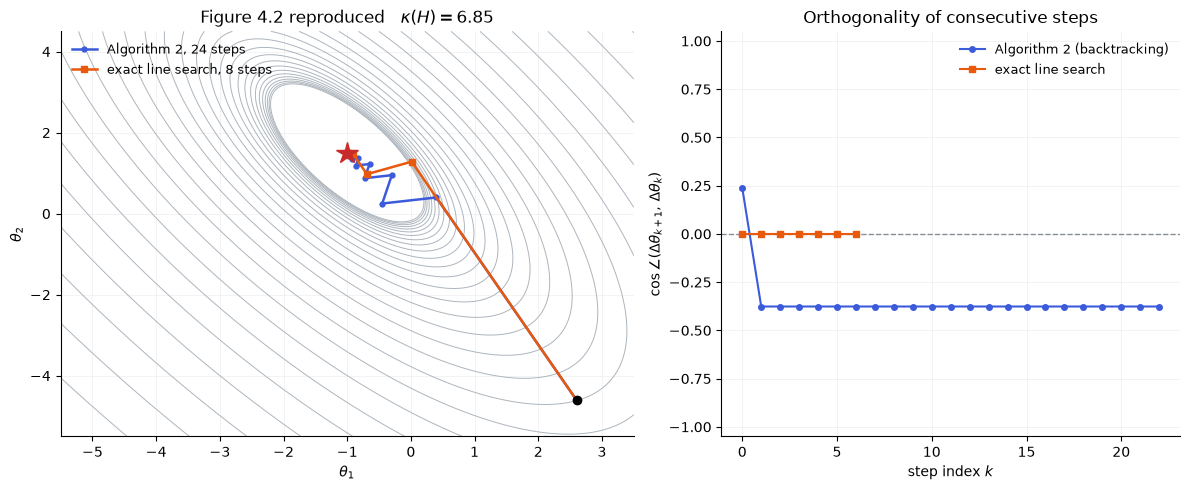

In [14]:
# Question 3: Reproduce Figure 4.2 (Notes, Chapter 4, Exercise 20)
import numpy as np, matplotlib.pyplot as plt

def cost_function(theta):
    return 2*theta[0]**2 + 2*theta[0]*theta[1] + theta[1]**2 + theta[0] - theta[1]

def cost_gradient(theta):
    return np.array([4*theta[0] + 2*theta[1] + 1,
                     2*theta[0] + 2*theta[1] - 1])

H_hess = np.array([[4., 2.], [2., 2.]])        # J = 0.5 th' H th + b' th,  b = (1,-1)

# ---- Algorithm 1: backtracking line search (delta restarts at 1 on every call) ----
def backtracking_line_search(theta, delta=1.0, max_halvings=60):
    grad, J0 = cost_gradient(theta), cost_function(theta)
    theta_new, k = theta - delta*grad, 0
    while cost_function(theta_new) >= J0 and k < max_halvings:
        delta /= 2.0
        theta_new = theta - delta*grad
        k += 1
    return theta_new, delta

# ---- Algorithm 2: steepest gradient descent, stopping criterion (i) ----
def steepest_descent(theta_0, tau1=1e-3, N=100000):
    hist, deltas, theta = [theta_0], [], theta_0
    for _ in range(int(N)):
        if np.linalg.norm(cost_gradient(theta)) < tau1:      # criterion (i)
            break
        theta, d = backtracking_line_search(theta)
        hist.append(theta); deltas.append(d)
    return np.array(hist), len(hist)-1, np.array(deltas)

# ---- exact line search, for the orthogonality check (Exercise 10) ----
def steepest_descent_exact(theta_0, tau1=1e-3, N=100000):
    hist, theta = [theta_0], theta_0
    for _ in range(int(N)):
        gr = cost_gradient(theta)
        if np.linalg.norm(gr) < tau1:
            break
        theta = theta - (gr @ gr)/(gr @ H_hess @ gr) * gr    # argmin of phi(alpha)
        hist.append(theta)
    return np.array(hist), len(hist)-1

def consecutive_cosines(hist):
    D = np.diff(hist, axis=0)
    D = D[np.linalg.norm(D, axis=1) > 1e-14]
    return np.array([D[k+1] @ D[k] / (np.linalg.norm(D[k+1])*np.linalg.norm(D[k]))
                     for k in range(len(D)-1)])

theta0, theta_star = np.array([2.6, -4.6]), np.array([-1., 1.5])
Hb, Nb, deltas = steepest_descent(theta0)
He, Ne         = steepest_descent_exact(theta0)
cos_b, cos_e   = consecutive_cosines(Hb), consecutive_cosines(He)
ev = np.linalg.eigvalsh(H_hess); kappa = ev[-1]/ev[0]

print(f"Algorithm 2 (backtracking): {Nb} iterations, theta = {Hb[-1]}")
print(f"Exact line search         : {Ne} iterations, theta = {He[-1]}")
print(f"max |cos| backtracking = {np.abs(cos_b).max():.4f}   (NOT orthogonal)")
print(f"max |cos| exact        = {np.abs(cos_e).max():.2e}   (orthogonal)")
print(f"kappa(H) = {kappa:.4f},  (kappa-1)/(kappa+1) = {(kappa-1)/(kappa+1):.4f}")
err = np.linalg.norm(Hb - theta_star, axis=1)
print(f"observed error contraction = {(err[1:]/err[:-1])[3:-3].mean():.4f}")
assert np.allclose(cos_e, 0.0, atol=1e-8), "exact line search should give orthogonal steps"

# ---- plots ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={"width_ratios": [1.25, 1]})
T1, T2 = np.meshgrid(np.linspace(-5.5, 3.5, 300), np.linspace(-5.5, 4.5, 300))
ax1.contour(T1, T2, 2*T1**2 + 2*T1*T2 + T2**2 + T1 - T2,
            levels=np.geomspace(.2, 120, 28), colors="#adb5bd", linewidths=.7)
ax1.plot(*Hb.T, "-o", ms=3.5, lw=1.8, color="#3b5bdb", label=f"Algorithm 2, {Nb} steps")
ax1.plot(*He.T, "-s", ms=4,   lw=1.8, color="#e8590c", label=f"exact line search, {Ne} steps")
ax1.plot(*theta_star, "*", ms=16, color="#c92a2a", zorder=5)
ax1.plot(*theta0, "ko", ms=6)
ax1.set(xlabel=r"$\theta_1$", ylabel=r"$\theta_2$",
        title=rf"Figure 4.2 reproduced   $\kappa(H)={kappa:.2f}$")
ax1.legend(frameon=False, loc="upper left", fontsize=9)

ax2.axhline(0, color="#868e96", lw=1, ls="--")
ax2.plot(cos_b, "-o", ms=4, color="#3b5bdb", label="Algorithm 2 (backtracking)")
ax2.plot(cos_e, "-s", ms=5, color="#e8590c", label="exact line search")
ax2.set(xlabel="step index $k$", ylim=(-1.05, 1.05),
        ylabel=r"$\cos\angle(\Delta\theta_{k+1},\,\Delta\theta_k)$",
        title="Orthogonality of consecutive steps")
ax2.legend(frameon=False, fontsize=9)
for ax in (ax1, ax2):
    ax.grid(alpha=.2, lw=.5); ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout(); plt.savefig("HW2Problem3.png", dpi=150)

---

## Question 4

*Notes, Chapter 5, Exercise 6.*

In Example 5.3.1, the union bound gave $\mathbb{P}[\text{some failure}] \le 0.0200$ for $m = 200$ components at $10^{-4}$ each. Recompute the bound and, assuming independence, the exact value for $m = 2000$ and $m = 5000$. At what $m$ does the bound stop saying anything at all, and what is the exact probability there?


---

## Question 5

*Notes, Chapter 5, Exercise 11.*

Let $A$ be the event "tests positive" and $B$ the event "has the disease", with
$$\mathbb{P}[A \mid B] = 0.99, \qquad \mathbb{P}[A' \mid B'] = 0.9999, \qquad \mathbb{P}[B] = 0.01 .$$

**(5.a)** Compute $\mathbb{P}[B \mid A]$, and for a population of 10 000 count how many are sick, how many sick people test negative, and how many healthy people test positive.

**(5.b)** Compare with Example 5.3.5, which has the same prevalence and a similar sensitivity yet yields a posterior of only $0.161$. Identify the single parameter responsible for the difference and say by what factor it changed.

**(5.c)** Hold the prevalence at $0.01$ and find the largest false-positive rate for which $\mathbb{P}[B \mid A] \ge 0.9$.


---

## Question 6

*Notes, Chapter 5, Exercise 14.*

Proposition 5.5.2 shows that independence implies zero covariance. Show that the converse fails: construct random variables $X$ and $Y$ with $\mathrm{Cov}(X, Y) = 0$ that are not independent.

*Hint:* try $Y = X^2$ with $X$ symmetric about zero.


---

## Question 7

*Notes, Chapter 5, Exercise 24.*

Verify Theorem 5.6.2 empirically.

**(7.a)** For $M \sim \mathcal{U}[0,1]$, estimate $\mathbb{E}[M]$ from $N$ samples, repeating 500 times for each $N$ to estimate the mean square error. Use
$$N \in \{10,\ 10^2,\ 10^3,\ 10^4,\ 10^5\}.$$
Plot $\sqrt{\mathbb{E}\big[(S_N - \bar m)^2\big]}$ against $N$ on log-log axes, fit a slope, and compare with the predicted $-1/2$. Report the fitted slope.

**(7.b)** Repeat (7.a) with $M$ drawn from a Student $t$ distribution with $1.5$ degrees of freedom, which has a finite mean and infinite variance. Report what you observe and explain why the slope is no longer $-1/2$, identifying which hypothesis of Theorem 5.6.2 has failed.

Two practical notes. Vectorize the 500 repetitions with `jax.vmap` rather than looping in Python. In (7.b) the empirical mean square error is itself heavy tailed across the 500 repetitions, so the points will scatter and will move when you change the seed; report what you see rather than forcing a clean fit.


[0.08948574 0.02840183 0.00920251 0.00283073 0.0009176 ]
fitted slope: -0.4980


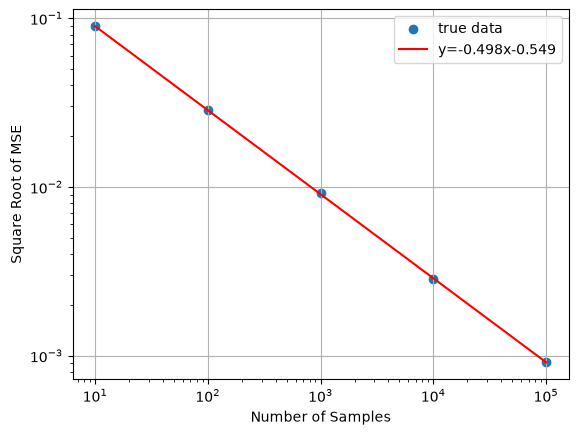

In [12]:
import matplotlib.pyplot as plt

key = jax.random.PRNGKey(0)

N_values = [10, 10**2, 10**3, 10**4, 10**5]
n_repeats = 500

# (7.a) your code here
def singular_estimate(key, N):
    samples = jax.random.uniform(key, shape=(N,))
    return jnp.mean(samples)

def MSE_batch(key, N, n_iters, true_mean):
    keys = jax.random.split(key, n_repeats)
    batch_est = jax.vmap(singular_estimate, in_axes=(0,None))(keys,N)
    return jnp.mean((batch_est - true_mean)**2)

root_MSE = []
for N in N_values:
    key, subkey = jax.random.split(key)
    root_MSE.append(jnp.sqrt(MSE_batch(subkey, N, n_repeats, true_mean=0.5)))

print(np.array(root_MSE))

slope, intercept = np.polyfit(np.log10(N_values), np.log10(root_MSE), deg=1)
print(f"fitted slope: {slope:.4f}")

plt.figure()
plt.scatter(N_values,np.array(root_MSE), label='true data')
plt.xlabel("Number of Samples")
plt.ylabel("Square Root of MSE")
N_arr = np.array(N_values)
fit_line = 10**intercept * N_arr**slope
plt.loglog(N_arr, fit_line, '-', label=f'y={slope:.3f}x{intercept:.3f}', color="red")
plt.xscale('log')
plt.yscale('log')
plt.grid()
plt.legend()

plt.savefig("HW2Problem7a.png")

[3.25284321 7.16443818 0.61080916 0.53082939 0.5069498 ]
fitted slope: -0.2745


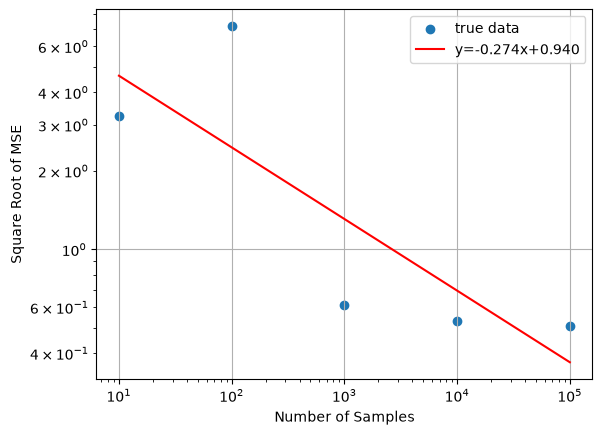

In [13]:
# (7.b) your code here

import matplotlib.pyplot as plt

key = jax.random.PRNGKey(0)

N_values = [10, 10**2, 10**3, 10**4, 10**5]
n_repeats = 500

def singular_estimate(key, N):
    samples = jax.random.t(key, df=1.5, shape=(N,))
    return jnp.mean(samples)

def MSE_batch(key, N, n_iters, true_mean):
    keys = jax.random.split(key, n_repeats)
    batch_est = jax.vmap(singular_estimate, in_axes=(0,None))(keys,N)
    return jnp.mean((batch_est - true_mean)**2)

root_MSE = []
for N in N_values:
    key, subkey = jax.random.split(key)
    root_MSE.append(jnp.sqrt(MSE_batch(subkey, N, n_repeats, true_mean=0.5)))

print(np.array(root_MSE))

slope, intercept = np.polyfit(np.log10(N_values), np.log10(root_MSE), deg=1)
print(f"fitted slope: {slope:.4f}")

plt.figure()
plt.scatter(N_values,np.array(root_MSE), label='true data')
plt.xlabel("Number of Samples")
plt.ylabel("Square Root of MSE")
N_arr = np.array(N_values)
fit_line = 10**intercept * N_arr**slope
plt.loglog(N_arr, fit_line, '-', label=f'y={slope:.3f}x+{intercept:.3f}', color="red")
plt.xscale('log')
plt.yscale('log')
plt.grid()
plt.legend()

plt.savefig("HW2Problem7b.png")

---

## Question 8

*Notes, Chapter 6, Exercise 2.*

A model $f$ incurs loss $0.2$ on a region carrying probability $0.95$ and loss $50$ on the remaining $0.05$; a second model $g$ incurs loss $1.2$ everywhere.

**(8.a)** Compute $R_\varepsilon(f)$ and $R_\varepsilon(g)$ for $\varepsilon = 1$ and for $\varepsilon = 0.1$.

**(8.b)** For $\varepsilon = 1$, give the smallest $\gamma$ for which each model is $(\varepsilon, \gamma)$-accurate, or say that none exists.

**(8.c)** Compute $\mathbb{E}[L]$ for both. One model is preferred by Definition 6.2.2 at $\varepsilon = 1$ and the other by expected loss. Say in one sentence why the two criteria disagree, and which one Theorem 6.3.1 controls.


---

## Question 9

*Notes, Chapter 6, Exercise 10.*

Prove Proposition 6.5.1: for every $\lambda > 0$, the matrix $\boldsymbol\Phi^{\mathsf T}\boldsymbol\Phi + \lambda \boldsymbol{I}$ is invertible, regardless of the rank of $\boldsymbol\Phi$.

*Hint:* show that $\boldsymbol{z}^{\mathsf T}(\boldsymbol\Phi^{\mathsf T}\boldsymbol\Phi + \lambda \boldsymbol{I})\boldsymbol{z} \ge \lambda \lVert \boldsymbol{z} \rVert^2$ for all $\boldsymbol{z}$.


---

## Question 10

*Notes, Chapter 6, Exercise 12.*

Express the ridge solution in terms of the singular value decomposition $\boldsymbol\Phi = \boldsymbol U \boldsymbol\Sigma \boldsymbol V^{\mathsf T}$. Show that the effect of $\lambda$ is to replace each singular value $\sigma_j$ by $\sigma_j / (\sigma_j^2 + \lambda)$, and explain why this suppresses the directions associated with small $\sigma_j$, the very directions that Figure 3.3b showed were badly conditioned.


---

## Question 11

*Notes, Chapter 6, Exercise 29.*

Reproduce Example 6.5.1. Generate $n = 60$ samples with $x_2 = x_1 + 0.02\varepsilon$, response $3x_1$ plus noise $0.3$, and fit by least squares. Repeat over 200 independent draws and report the standard deviation of $\theta_1$, of $\theta_2$, and of $\theta_1 + \theta_2$. Then repeat with ridge at $\lambda = 10^{-2}$. Which of the three standard deviations does regularization actually reduce, and which was already small?


In [5]:
# Question 11: your code here
import matplotlib.pyplot as plt

key = jax.random.PRNGKey(0)
n_draws, n_samples, lambda_ = 200, 60, 1e-2

def generate_samples(key, N):
    key1, key2, key3 = jax.random.split(key, 3)
    x1 = jax.random.normal(key1, shape=(N,))
    x2 = x1 + 0.02*jax.random.normal(key2, shape=(N,))
    y = 3*x1 + 0.3*jax.random.normal(key3, shape=(N,)) # response noise σ = 0.3
    
    return jnp.stack([x1, x2], axis=1), y

# solve using ridge solution
def solve_L2(key, N, ridge):
    Phi, y = generate_samples(key, N)
    theta = jnp.linalg.solve((Phi.T@Phi)/N + ridge*jnp.eye(2), Phi.T@y/N)
    return theta

keys = jax.random.split(key, n_draws)
theta_ols   = jax.vmap(solve_L2, in_axes=(0, None, None))(keys, n_samples, 0.0)
theta_ridge = jax.vmap(solve_L2, in_axes=(0, None, None))(keys, n_samples, lambda_)

for name, T in [("OLS", theta_ols), ("ridge 1e-2", theta_ridge)]:
    s = T[:,0] + T[:,1]
    print(f"{name:12s} std(t1)={T[:,0].std():.4f}  std(t2)={T[:,1].std():.4f}  "
          f"std(t1+t2)={s.std():.4f}  mean(t1+t2)={s.mean():.4f}")

OLS          std(t1)=1.7128  std(t2)=1.7089  std(t1+t2)=0.0387  mean(t1+t2)=3.0025
ridge 1e-2   std(t1)=0.0401  std(t2)=0.0373  std(t1+t2)=0.0384  mean(t1+t2)=2.9863


---

## Question 12

*Notes, Chapter 6, Exercise 31.*

Reproduce the three sample sizes 336, 613 and 1681 of Example 6.3.1 from Corollary 6.3.2, then plot $n$ against $\log_{10} H$ for fixed $\gamma$, and against $\gamma$ for fixed $H$. One plot is a straight line and the other is a hyperbola. Which is which, and which of the two shapes is the reason a large hyperparameter search is affordable?

The two plots may be produced with code or drawn by hand; what matters is the shape of each dependence.


H=1e6   gamma=0.05   n=  336.225 -> 336
H=1e12  gamma=0.05   n=  612.535 -> 613
H=1e6   gamma=0.01   n= 1681.124 -> 1681


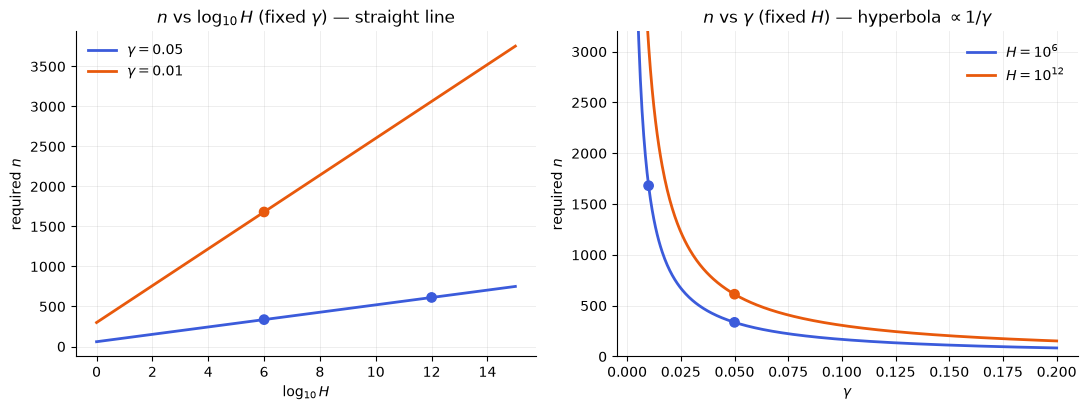

In [7]:
# Question 12: code goes here
import matplotlib.pyplot as plt

DELTA = 0.05
def n_required(H, gamma, delta=DELTA):
    """Corollary 6.3.2:  H exp(-gamma n) <= delta  <=>  n >= (ln H + ln(1/delta))/gamma"""
    return (np.log(H) + np.log(1/delta)) / gamma

for H, g in [(1e6, 0.05), (1e12, 0.05), (1e6, 0.01)]:
    print(f"H=1e{int(np.log10(H)):<3d} gamma={g:<5}  n={n_required(H,g):9.3f} -> {round(n_required(H,g))}")

C = ["#3b5bdb", "#e8590c"]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))

L = np.linspace(0, 15, 400)                      # left: fixed gamma -> LINE
for c, g in zip(C, [0.05, 0.01]):
    ax1.plot(L, n_required(10.0**L, g), lw=2, color=c, label=rf"$\gamma={g}$")
ax1.scatter([6, 12, 6], [336, 613, 1681], s=45, color=["#3b5bdb"]*2 + ["#e8590c"], zorder=3)
ax1.set(xlabel=r"$\log_{10} H$", ylabel="required $n$",
        title=r"$n$ vs $\log_{10}H$ (fixed $\gamma$) — straight line")

gam = np.linspace(0.005, 0.2, 500)               # right: fixed H -> HYPERBOLA
for c, H in zip(C, [1e6, 1e12]):
    ax2.plot(gam, n_required(H, gam), lw=2, color=c, label=rf"$H=10^{{{int(np.log10(H))}}}$")
ax2.scatter([.05, .01, .05], [336, 1681, 613], s=45, color=["#3b5bdb"]*2 + ["#e8590c"], zorder=3)
ax2.set(xlabel=r"$\gamma$", ylabel="required $n$", ylim=(0, 3200),
        title=r"$n$ vs $\gamma$ (fixed $H$) — hyperbola $\propto 1/\gamma$")

for ax in (ax1, ax2):
    ax.legend(frameon=False); ax.grid(alpha=.25, lw=.6)
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()

plt.savefig("HW2Problem12.png")